In [131]:
from pathlib import Path
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42

DATA_PATHS = [
    Path("../data/raw/laptops_cleaned.csv"),
    Path("data/raw/laptops_cleaned.csv"),
]
# Try to find the data file in the specified paths
data_path = next((p for p in DATA_PATHS if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Could not find laptops_cleaned.csv in the expected locations.")

df = pd.read_csv(data_path)

target = "price"
# Define the feature set (ex the target variable)
feature_set_a = [
    "brand",
    "device_category",
    "rating",
    "cpu_brand",
    "cpu_family",
    "cpu_core_count",
    "cpu_thread_count",
    "ram_gb",
    "storage_gb",
    "display_width_px",
    "display_height_px",
    "display_size_inch",
    "gpu_brand",
    "gpu_type",
    "gpu_vram_gb",
    "os_name",
    "warranty_years",
]
# Check for missing columns in the DataFrame
missing_columns = sorted(set(feature_set_a + [target]) - set(df.columns))
if missing_columns:
    raise ValueError(f"Missing expected columns: {missing_columns}")
# Prepare feature matrix X and target vector y
X = df[feature_set_a].copy()
y = df[target].copy()
# Print the shapes of X and y, and the feature columns
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())

X shape: (992, 17)
y shape: (992,)

Feature columns:
['brand', 'device_category', 'rating', 'cpu_brand', 'cpu_family', 'cpu_core_count', 'cpu_thread_count', 'ram_gb', 'storage_gb', 'display_width_px', 'display_height_px', 'display_size_inch', 'gpu_brand', 'gpu_type', 'gpu_vram_gb', 'os_name', 'warranty_years']


In [132]:
# Identify numeric and categorical features
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['rating', 'cpu_core_count', 'cpu_thread_count', 'ram_gb', 'storage_gb', 'display_width_px', 'display_height_px', 'display_size_inch', 'gpu_vram_gb', 'warranty_years']

Categorical features:
['brand', 'device_category', 'cpu_brand', 'cpu_family', 'gpu_brand', 'gpu_type', 'os_name']


In [133]:
# Check for missing values in the feature matrix X
X.isnull().sum().sort_values(ascending=False)

gpu_vram_gb          700
gpu_type               8
gpu_brand              8
brand                  0
device_category        0
cpu_core_count         0
rating                 0
cpu_brand              0
cpu_family             0
storage_gb             0
ram_gb                 0
cpu_thread_count       0
display_width_px       0
display_size_inch      0
display_height_px      0
os_name                0
warranty_years         0
dtype: int64

In [134]:
# Define preprocessing pipelines for numeric and categorical features
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

numeric_transformer_linear = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_transformer_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])
# Combine preprocessing steps into ColumnTransformers for linear and tree-based models
preprocessor_linear = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_linear, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)
# The tree based preprocessor doesnt include scaling for numeric features
preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_tree, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)
# Print preprocessors to verify structure
print("Preprocessors created successfully.")

Preprocessors created successfully.


In [135]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (793, 17)
X_test : (199, 17)
y_train: (793,)
y_test : (199,)


In [136]:
# Apply the linear preprocessor to the training and testing data
X_train_linear = preprocessor_linear.fit_transform(X_train)
X_test_linear = preprocessor_linear.transform(X_test)

# Check on the shapes after transforming
print("Transformed train shape:", X_train_linear.shape)
print("Transformed test shape :", X_test_linear.shape)

Transformed train shape: (793, 59)
Transformed test shape : (199, 59)


In [137]:
# Get feature names after transformation for linear preprocessor
feature_names_linear = preprocessor_linear.get_feature_names_out()
pd.Series(feature_names_linear, name="transformed_feature").head(30)

0                          num__rating
1                  num__cpu_core_count
2                num__cpu_thread_count
3                          num__ram_gb
4                      num__storage_gb
5                num__display_width_px
6               num__display_height_px
7               num__display_size_inch
8                     num__gpu_vram_gb
9                  num__warranty_years
10                     cat__brand_acer
11                cat__brand_alienware
12                    cat__brand_apple
13                     cat__brand_asus
14                    cat__brand_chuwi
15                 cat__brand_colorful
16                     cat__brand_dell
17                 cat__brand_gigabyte
18                       cat__brand_hp
19                  cat__brand_infinix
20                   cat__brand_lenovo
21                cat__brand_microsoft
22                 cat__brand_motorola
23                      cat__brand_msi
24                  cat__brand_samsung
25                  cat__

In [138]:
# Get feature names after transformation for tree based preprocessor
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline

In [139]:
# Define paths for saving metrics and figures
METRICS_DIR = Path("../outputs/metrics")
FIGURES_DIR = Path("../outputs/figures")

METRICS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Metrics path:", METRICS_DIR.resolve())
print("Figures path:", FIGURES_DIR.resolve())

Metrics path: C:\Users\Felix\Documents\University\Master\Master\COM763 Advanced Machine Learning\Assignments\Assignment 1\Git\streamlit-regression-app\outputs\metrics
Figures path: C:\Users\Felix\Documents\University\Master\Master\COM763 Advanced Machine Learning\Assignments\Assignment 1\Git\streamlit-regression-app\outputs\figures


In [140]:
# Define models with their respective pipelines
models = {
    "DummyRegressor": DummyRegressor(strategy="mean"),
    "Ridge": Pipeline(steps=[
        ("preprocessor", preprocessor_linear),
        ("model", Ridge(alpha=1.0))
    ])
}

print(models)

{'DummyRegressor': DummyRegressor(), 'Ridge': Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['rating', 'cpu_core_count',
                                                   'cpu_thread_count', 'ram_gb',
                                                   'storage_gb',
                                                   'display_width_px',
                                                   'display_height_px',
                                                   'display_size_inch',
                                                   'gpu_vram_gb',
             

In [141]:
# Function to evaluate a regression model using cross validation and test set performance
def evaluate_regressor(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    cv,
    model_name
):
    scoring = {
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    }
    
# Perform cross validatin and compute metrics
    cv_results = cross_validate(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    fitted_model = clone(model)
    fitted_model.fit(X_train, y_train)
    y_pred = fitted_model.predict(X_test)

    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    test_mae = mean_absolute_error(y_test, y_pred)
    test_r2 = r2_score(y_test, y_pred)

# Compile results into a dictionary
    result = {
        "model": model_name,
        "cv_rmse_mean": -cv_results["test_rmse"].mean(),
        "cv_rmse_std": cv_results["test_rmse"].std(),
        "cv_mae_mean": -cv_results["test_mae"].mean(),
        "cv_mae_std": cv_results["test_mae"].std(),
        "cv_r2_mean": cv_results["test_r2"].mean(),
        "cv_r2_std": cv_results["test_r2"].std(),
        "test_rmse": test_rmse,
        "test_mae": test_mae,
        "test_r2": test_r2
    }

    return result, fitted_model, y_pred

In [142]:
# Define cross validation strategy
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print(cv)

KFold(n_splits=5, random_state=42, shuffle=True)


In [143]:
# Evaluate each model and store results, fitted models, and test predictions 
results = []
fitted_models = {}
test_predictions = {}

# Loop through each model, evaluate, and store results
for model_name, model in models.items():
    result, fitted_model, y_pred = evaluate_regressor(
        model=model,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        cv=cv,
        model_name=model_name
    )

    results.append(result)
    fitted_models[model_name] = fitted_model
    test_predictions[model_name] = y_pred

# Create DataFrame to compare model performance
model_comparison_v1 = (
    pd.DataFrame(results)
    .sort_values(by="test_rmse", ascending=True)
    .reset_index(drop=True)
)

model_comparison_v1

,model,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,cv_r2_mean,cv_r2_std,test_rmse,test_mae,test_r2
0,Ridge,20616.708270,772.328554,13508.843119,480.360921,0.892535,0.013536,18899.182942,13544.408959,0.951087
1,DummyRegressor,63407.589211,2744.891777,42614.173500,1820.671897,-0.008106,0.009222,86279.191190,53148.974133,-0.019418


In [144]:
# Display the model comparison df with formatting for better readability
display(
    model_comparison_v1.style.format({
        "cv_rmse_mean": "{:.2f}",
        "cv_rmse_std": "{:.2f}",
        "cv_mae_mean": "{:.2f}",
        "cv_mae_std": "{:.2f}",
        "cv_r2_mean": "{:.4f}",
        "cv_r2_std": "{:.4f}",
        "test_rmse": "{:.2f}",
        "test_mae": "{:.2f}",
        "test_r2": "{:.4f}",
    })
)

,model,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,cv_r2_mean,cv_r2_std,test_rmse,test_mae,test_r2
0,Ridge,20616.71,772.33,13508.84,480.36,0.8925,0.0135,18899.18,13544.41,0.9511
1,DummyRegressor,63407.59,2744.89,42614.17,1820.67,-0.0081,0.0092,86279.19,53148.97,-0.0194


In [145]:
# Save the model comparison df to csv
comparison_path = METRICS_DIR / "model_comparison_v1.csv"
model_comparison_v1.to_csv(comparison_path, index=False)

print(f"Saved model comparison to: {comparison_path}")

Saved model comparison to: ..\outputs\metrics\model_comparison_v1.csv


In [146]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

In [147]:
# Define a new model with a random forest regressor and the tree based preprocessor
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# Add new model to the models dictionary for evaluation
models_v2 = {
    "DummyRegressor": DummyRegressor(strategy="mean"),
    "Ridge": Pipeline(steps=[
        ("preprocessor", preprocessor_linear),
        ("model", Ridge(alpha=1.0))
    ]),
    "RandomForest": rf_model
}

print(models_v2.keys())

dict_keys(['DummyRegressor', 'Ridge', 'RandomForest'])


In [148]:
# Evaluate each model and store results, fitted models. Test predictions for the new set of models
results_v2 = []
fitted_models_v2 = {}
test_predictions_v2 = {}

for model_name, model in models_v2.items():
    result, fitted_model, y_pred = evaluate_regressor(
        model=model,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        cv=cv,
        model_name=model_name
    )

# Add results and store fitted models and predictions
    results_v2.append(result)
    fitted_models_v2[model_name] = fitted_model
    test_predictions_v2[model_name] = y_pred

model_comparison_v2 = (
    pd.DataFrame(results_v2)
    .sort_values(by="test_rmse", ascending=True)
    .reset_index(drop=True)
)

model_comparison_v2

,model,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,cv_r2_mean,cv_r2_std,test_rmse,test_mae,test_r2
0,Ridge,20616.708270,772.328554,13508.843119,480.360921,0.892535,0.013536,18899.182942,13544.408959,0.951087
1,RandomForest,18687.778204,1463.715362,11374.818742,904.170832,0.910944,0.018086,23678.319671,12900.526213,0.923221
2,DummyRegressor,63407.589211,2744.891777,42614.173500,1820.671897,-0.008106,0.009222,86279.191190,53148.974133,-0.019418


In [149]:
# Display the model comparison df with formatting for better readability
display(
    model_comparison_v2.style.format({
        "cv_rmse_mean": "{:.2f}",
        "cv_rmse_std": "{:.2f}",
        "cv_mae_mean": "{:.2f}",
        "cv_mae_std": "{:.2f}",
        "cv_r2_mean": "{:.4f}",
        "cv_r2_std": "{:.4f}",
        "test_rmse": "{:.2f}",
        "test_mae": "{:.2f}",
        "test_r2": "{:.4f}",
    })
)

,model,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,cv_r2_mean,cv_r2_std,test_rmse,test_mae,test_r2
0,Ridge,20616.71,772.33,13508.84,480.36,0.8925,0.0135,18899.18,13544.41,0.9511
1,RandomForest,18687.78,1463.72,11374.82,904.17,0.9109,0.0181,23678.32,12900.53,0.9232
2,DummyRegressor,63407.59,2744.89,42614.17,1820.67,-0.0081,0.0092,86279.19,53148.97,-0.0194


In [150]:
# Save the model comparison df to csv
comparison_v2_path = METRICS_DIR / "model_comparison_v2.csv"
model_comparison_v2.to_csv(comparison_v2_path, index=False)

print(f"Saved model comparison to: {comparison_v2_path}")

Saved model comparison to: ..\outputs\metrics\model_comparison_v2.csv


In [151]:
# Analyse feature importance for the rf model
rf_fitted = fitted_models_v2["RandomForest"]
rf_preprocessor = rf_fitted.named_steps["preprocessor"]
rf_estimator = rf_fitted.named_steps["model"]

rf_feature_names = rf_preprocessor.get_feature_names_out()
rf_importances = rf_estimator.feature_importances_

feature_importance_df = pd.DataFrame({
    "transformed_feature": rf_feature_names,
    "importance": rf_importances
}).sort_values(by="importance", ascending=False).reset_index(drop=True)

feature_importance_df.head(20)

,transformed_feature,importance
0,num__rating,0.400069
1,num__display_width_px,0.139258
2,num__gpu_vram_gb,0.114937
3,num__ram_gb,0.082682
4,num__display_height_px,0.074340
5,num__cpu_core_count,0.074164
6,num__storage_gb,0.017397
7,num__cpu_thread_count,0.016808
8,cat__brand_dell,0.015456
9,num__display_size_inch,0.012021


In [152]:
raw_features_for_mapping = feature_set_a.copy()

def map_to_raw_feature(transformed_name: str, raw_features: list[str]) -> str:
    cleaned = transformed_name.replace("num__", "").replace("cat__", "")

    if transformed_name.startswith("num__"):
        return cleaned

    for raw_feature in sorted(raw_features, key=len, reverse=True):
        if cleaned == raw_feature or cleaned.startswith(raw_feature + "_"):
            return raw_feature

    return cleaned

# Add a column for raw feature names by applying the corrected mapping
feature_importance_df["raw_feature"] = feature_importance_df["transformed_feature"].apply(
    lambda x: map_to_raw_feature(x, raw_features_for_mapping)
)

# Group by raw feature names and sum importance and sort by importance
grouped_feature_importance_df = (
    feature_importance_df
    .groupby("raw_feature", as_index=False)["importance"]
    .sum()
    .sort_values(by="importance", ascending=False)
    .reset_index(drop=True)
)

grouped_feature_importance_df

,raw_feature,importance
0,rating,0.400069
1,display_width_px,0.139258
2,gpu_vram_gb,0.114937
3,ram_gb,0.082682
4,display_height_px,0.074340
5,cpu_core_count,0.074164
6,brand,0.031320
7,storage_gb,0.017397
8,cpu_thread_count,0.016808
9,display_size_inch,0.012021


In [153]:
# Save the grouped feature importance to csv
feature_importance_path = METRICS_DIR / "random_forest_feature_importance_grouped.csv"
grouped_feature_importance_df.to_csv(feature_importance_path, index=False)

print(f"Saved grouped feature importance to: {feature_importance_path}")

Saved grouped feature importance to: ..\outputs\metrics\random_forest_feature_importance_grouped.csv


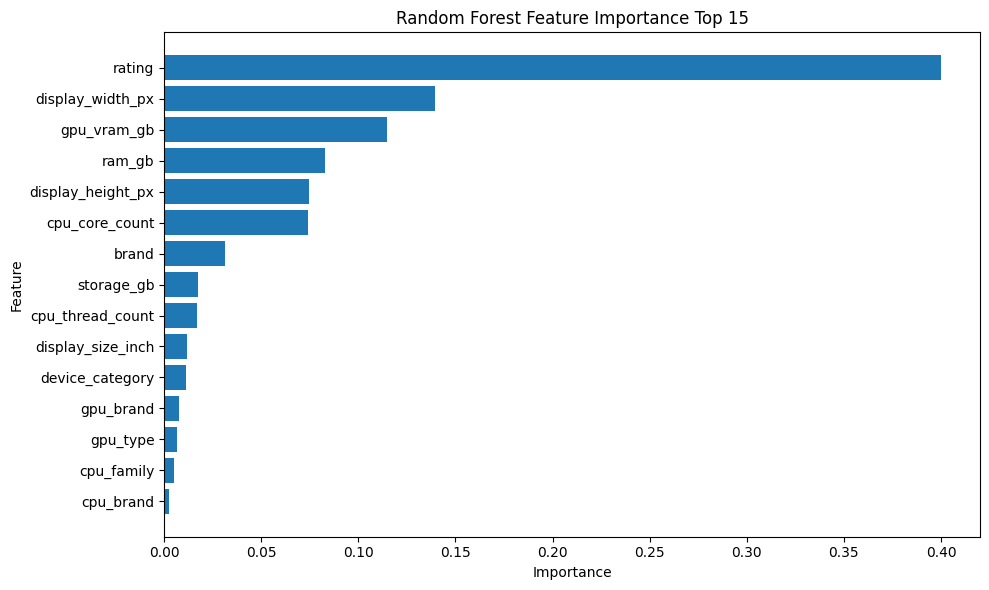

Saved plot to: ..\outputs\figures\random_forest_feature_importance_top15.png


In [154]:
# Plot the feature importance for the t 15 features
top_n = 15
top_features = grouped_feature_importance_df.head(top_n).sort_values(by="importance")

# horizontal bar plot for the top features
plt.figure(figsize=(10, 6))
plt.barh(top_features["raw_feature"], top_features["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(f"Random Forest Feature Importance Top {top_n}")
plt.tight_layout()

# Save the plot to figures directory
rf_importance_plot_path = FIGURES_DIR / "random_forest_feature_importance_top15.png"
plt.savefig(rf_importance_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved plot to: {rf_importance_plot_path}")

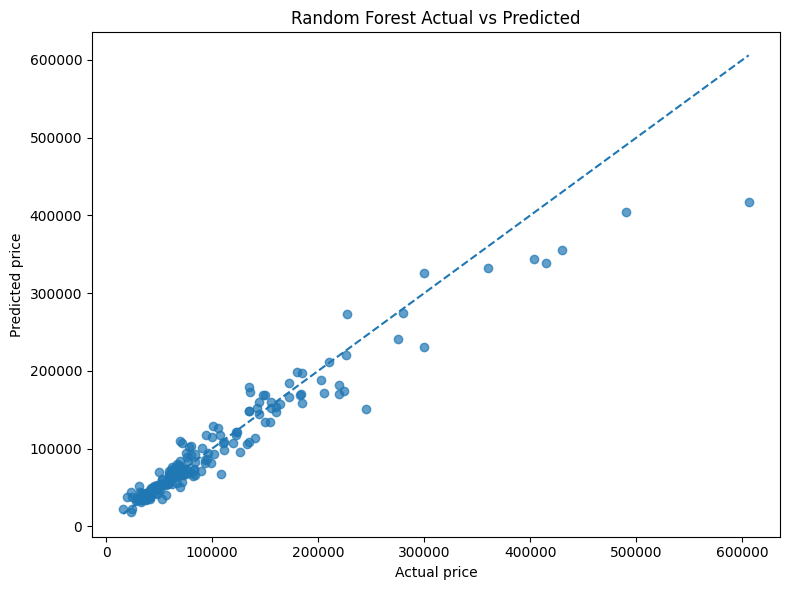

Saved plot to: ..\outputs\figures\random_forest_actual_vs_predicted_v1.png


In [155]:
# Plot actual vs predicted values for rf model
rf_actual = y_test.reset_index(drop=True)
rf_pred = pd.Series(test_predictions_v2["RandomForest"]).reset_index(drop=True)

plt.figure(figsize=(8, 6))
plt.scatter(rf_actual, rf_pred, alpha=0.7)
plt.plot(
    [rf_actual.min(), rf_actual.max()],
    [rf_actual.min(), rf_actual.max()],
    linestyle="--"
)
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Random Forest Actual vs Predicted")
plt.tight_layout()

rf_actual_pred_plot_path = FIGURES_DIR / "random_forest_actual_vs_predicted_v1.png"
plt.savefig(rf_actual_pred_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved plot to: {rf_actual_pred_plot_path}")

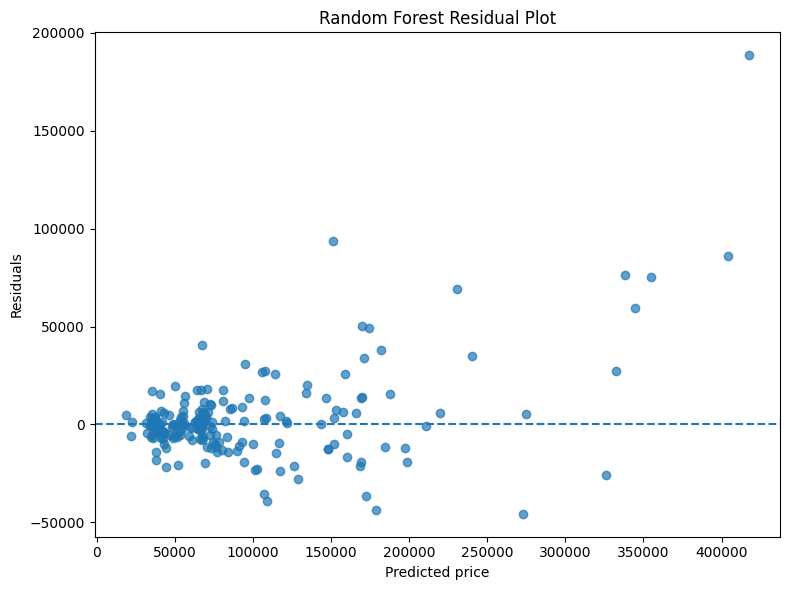

Saved plot to: ..\outputs\figures\random_forest_residual_plot_v1.png


In [156]:
# Plot residuals for rf model
rf_residuals = rf_actual - rf_pred

plt.figure(figsize=(8, 6))
plt.scatter(rf_pred, rf_residuals, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted price")
plt.ylabel("Residuals")
plt.title("Random Forest Residual Plot")
plt.tight_layout()

rf_residual_plot_path = FIGURES_DIR / "random_forest_residual_plot_v1.png"
plt.savefig(rf_residual_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved plot to: {rf_residual_plot_path}")

In [157]:
from sklearn.neural_network import MLPRegressor

In [158]:
# Define new model with a mlp regressor and the linear preprocessor
def make_dense_onehot():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer_mlp = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", make_dense_onehot())
])

numeric_transformer_mlp = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor_mlp = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_mlp, numeric_features),
        ("cat", categorical_transformer_mlp, categorical_features),
    ],
    remainder="drop",
    sparse_threshold=0
)

print("MLP preprocessor created.")

MLP preprocessor created.


In [159]:
# Define two versions of mlp regressor with different architectures and training parameters
mlp_v1 = Pipeline(steps=[
    ("preprocessor", preprocessor_mlp),
    ("model", MLPRegressor(
        hidden_layer_sizes=(64,),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        learning_rate_init=0.001,
        max_iter=500,
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20
    ))
])

mlp_v2 = Pipeline(steps=[
    ("preprocessor", preprocessor_mlp),
    ("model", MLPRegressor(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=800,
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=25
    ))
])

# Add new mlp models to the models dictionary for evaluation
models_v3 = {
    "DummyRegressor": DummyRegressor(strategy="mean"),
    "Ridge": Pipeline(steps=[
        ("preprocessor", preprocessor_linear),
        ("model", Ridge(alpha=1.0))
    ]),
    "RandomForest": Pipeline(steps=[
        ("preprocessor", preprocessor_tree),
        ("model", RandomForestRegressor(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),
    "MLP_v1": mlp_v1,
    "MLP_v2": mlp_v2
}

print(models_v3.keys())

dict_keys(['DummyRegressor', 'Ridge', 'RandomForest', 'MLP_v1', 'MLP_v2'])


In [160]:
# Evaluate models and results. Test predictions for new set of models including mlp regressors
results_v3 = []
fitted_models_v3 = {}
test_predictions_v3 = {}

for model_name, model in models_v3.items():
    result, fitted_model, y_pred = evaluate_regressor(
        model=model,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        cv=cv,
        model_name=model_name
    )

    results_v3.append(result)
    fitted_models_v3[model_name] = fitted_model
    test_predictions_v3[model_name] = y_pred

model_comparison_v3 = (
    pd.DataFrame(results_v3)
    .sort_values(by="test_rmse", ascending=True)
    .reset_index(drop=True)
)

model_comparison_v3

,model,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,cv_r2_mean,cv_r2_std,test_rmse,test_mae,test_r2
0,Ridge,20616.708270,772.328554,13508.843119,480.360921,0.892535,0.013536,18899.182942,13544.408959,0.951087
1,MLP_v2,22850.717876,1074.005467,14938.996535,1047.128035,0.867612,0.020482,19750.219043,14299.907194,0.946582
2,RandomForest,18687.778204,1463.715362,11374.818742,904.170832,0.910944,0.018086,23678.319671,12900.526213,0.923221
3,DummyRegressor,63407.589211,2744.891777,42614.173500,1820.671897,-0.008106,0.009222,86279.191190,53148.974133,-0.019418
4,MLP_v1,106240.577287,3623.991892,85346.864811,4548.265488,-1.845702,0.278037,129456.748132,97251.309635,-1.295036


In [161]:
# Display the model comparison df with formatting for better readability
display(
    model_comparison_v3.style.format({
        "cv_rmse_mean": "{:.2f}",
        "cv_rmse_std": "{:.2f}",
        "cv_mae_mean": "{:.2f}",
        "cv_mae_std": "{:.2f}",
        "cv_r2_mean": "{:.4f}",
        "cv_r2_std": "{:.4f}",
        "test_rmse": "{:.2f}",
        "test_mae": "{:.2f}",
        "test_r2": "{:.4f}",
    })
)

,model,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,cv_r2_mean,cv_r2_std,test_rmse,test_mae,test_r2
0,Ridge,20616.71,772.33,13508.84,480.36,0.8925,0.0135,18899.18,13544.41,0.9511
1,MLP_v2,22850.72,1074.01,14939.00,1047.13,0.8676,0.0205,19750.22,14299.91,0.9466
2,RandomForest,18687.78,1463.72,11374.82,904.17,0.9109,0.0181,23678.32,12900.53,0.9232
3,DummyRegressor,63407.59,2744.89,42614.17,1820.67,-0.0081,0.0092,86279.19,53148.97,-0.0194
4,MLP_v1,106240.58,3623.99,85346.86,4548.27,-1.8457,0.2780,129456.75,97251.31,-1.2950


In [162]:
# Save the model comparison df to csv
comparison_v3_path = METRICS_DIR / "model_comparison_v3.csv"
model_comparison_v3.to_csv(comparison_v3_path, index=False)

print(f"Saved model comparison to: {comparison_v3_path}")

Saved model comparison to: ..\outputs\metrics\model_comparison_v3.csv


In [163]:
# Extract training details from the mlp models for debugging and analysis
mlp_debug_rows = []

for model_name in ["MLP_v1", "MLP_v2"]:
    fitted_pipeline = fitted_models_v3[model_name]
    mlp_model = fitted_pipeline.named_steps["model"]

    mlp_debug_rows.append({
        "model": model_name,
        "n_iter": mlp_model.n_iter_,
        "final_loss": mlp_model.loss_,
        "best_validation_score": getattr(mlp_model, "best_validation_score_", None)
    })

mlp_debug_df = pd.DataFrame(mlp_debug_rows)
mlp_debug_df

,model,n_iter,final_loss,best_validation_score
0,MLP_v1,22,5.431145e+09,-1.352582
1,MLP_v2,774,1.932023e+08,0.912771


In [164]:
# Save the mlp debug info to csv    
mlp_debug_path = METRICS_DIR / "mlp_debug_info.csv"
mlp_debug_df.to_csv(mlp_debug_path, index=False)

print(f"Saved MLP debug info to: {mlp_debug_path}")

Saved MLP debug info to: ..\outputs\metrics\mlp_debug_info.csv


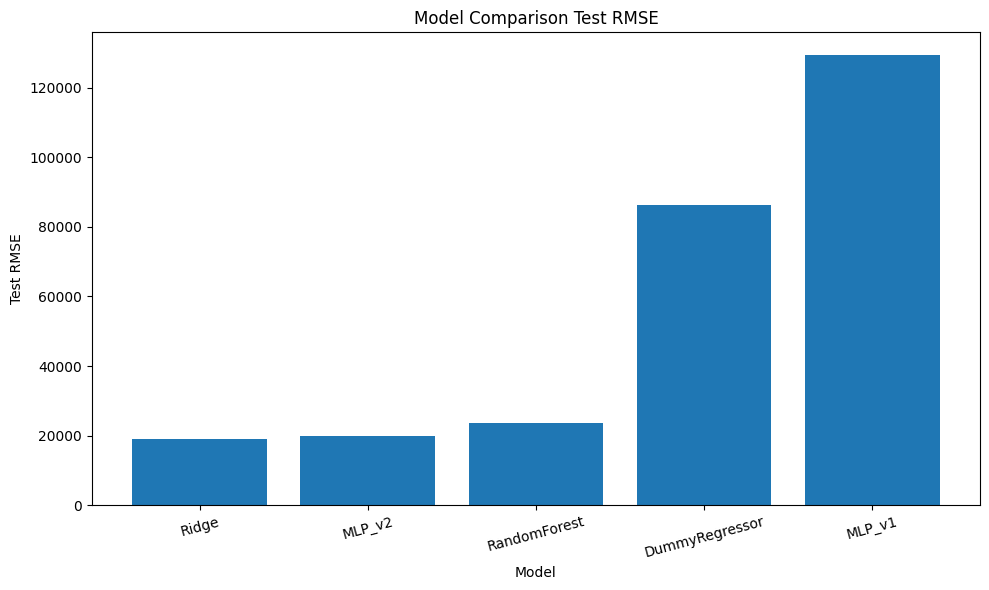

Saved RMSE comparison plot to: ..\outputs\figures\model_comparison_test_rmse_v3.png


In [165]:
# Plot the test rmse for all models in the comparison
rmse_plot_df = model_comparison_v3.sort_values("test_rmse", ascending=True)

plt.figure(figsize=(10, 6))
plt.bar(rmse_plot_df["model"], rmse_plot_df["test_rmse"])
plt.ylabel("Test RMSE")
plt.xlabel("Model")
plt.title("Model Comparison Test RMSE")
plt.xticks(rotation=15)
plt.tight_layout()

rmse_plot_path = FIGURES_DIR / "model_comparison_test_rmse_v3.png"
plt.savefig(rmse_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved RMSE comparison plot to: {rmse_plot_path}")

In [166]:
# Create a working copy of the OG df for further analysis and debugging
df_work = df.copy()

print("Working shape:", df_work.shape)

Working shape: (992, 27)


In [167]:
# Check for fully duplicated rows in working df
duplicate_count = df_work.duplicated().sum()
print("Number of fully duplicated rows:", duplicate_count)

if duplicate_count > 0:
    display(df_work[df_work.duplicated()].head(10))

Number of fully duplicated rows: 0


In [168]:
# Create a summary of missing values in the working df
missing_summary = pd.DataFrame({
    "missing_count": df_work.isnull().sum(),
    "missing_pct": (df_work.isnull().mean() * 100).round(2),
    "dtype": df_work.dtypes.astype(str)
}).sort_values(by="missing_pct", ascending=False)

display(missing_summary)

,missing_count,missing_pct,dtype
cpu_lp_e_cores,826,83.27,float64
gpu_vram_gb,700,70.56,float64
cpu_e_cores,311,31.35,float64
cpu_p_cores,289,29.13,float64
cpu_suffix,131,13.21,object
gpu_model,8,0.81,object
gpu_series,8,0.81,object
gpu_type,8,0.81,object
gpu_brand,8,0.81,object
model,0,0.00,object


In [169]:
# Perform plausibility checks on numeric columns to identify potential data quality issues
plausibility_checks = {
    "price_non_positive": (df_work["price"] <= 0).sum(),
    "rating_negative": (df_work["rating"] < 0).sum(),
    "ram_non_positive": (df_work["ram_gb"] <= 0).sum(),
    "storage_non_positive": (df_work["storage_gb"] <= 0).sum(),
    "display_size_non_positive": (df_work["display_size_inch"] <= 0).sum(),
    "display_width_non_positive": (df_work["display_width_px"] <= 0).sum(),
    "display_height_non_positive": (df_work["display_height_px"] <= 0).sum(),
    "cpu_core_count_non_positive": (df_work["cpu_core_count"] <= 0).sum(),
    "cpu_thread_count_non_positive": (df_work["cpu_thread_count"] <= 0).sum(),
    "gpu_vram_negative": (df_work["gpu_vram_gb"].fillna(0) < 0).sum(),
    "warranty_negative": (df_work["warranty_years"] < 0).sum(),
}

plausibility_df = pd.DataFrame(
    plausibility_checks.items(),
    columns=["check", "count"]
)

display(plausibility_df)

,check,count
0,price_non_positive,0
1,rating_negative,0
2,ram_non_positive,0
3,storage_non_positive,0
4,display_size_non_positive,0
5,display_width_non_positive,0
6,display_height_non_positive,0
7,cpu_core_count_non_positive,0
8,cpu_thread_count_non_positive,0
9,gpu_vram_negative,0


In [170]:
# Identify rows that fail any of the plausibility checks for further inspection
bad_rows = df_work[
    (df_work["price"] <= 0) |
    (df_work["ram_gb"] <= 0) |
    (df_work["storage_gb"] <= 0) |
    (df_work["display_size_inch"] <= 0) |
    (df_work["display_width_px"] <= 0) |
    (df_work["display_height_px"] <= 0) |
    (df_work["cpu_core_count"] <= 0) |
    (df_work["cpu_thread_count"] <= 0) |
    (df_work["warranty_years"] < 0)
]

print("Rows with obvious plausibility issues:", bad_rows.shape[0])
display(bad_rows.head(20))

Rows with obvious plausibility issues: 0


,brand,model,device_category,price,rating,cpu_brand,cpu_family,cpu_series,cpu_model,cpu_suffix,...,display_width_px,display_height_px,display_size_inch,gpu_brand,gpu_series,gpu_model,gpu_vram_gb,gpu_type,os_name,warranty_years


In [171]:
# Trim annoying whitespace in object columns and replace "nan" strings with actual NaN values
object_cols = df_work.select_dtypes(include="object").columns.tolist()

for col in object_cols:
    df_work[col] = df_work[col].astype(str).str.strip()
    df_work[col] = df_work[col].replace({"nan": np.nan})

print("Trimmed whitespace in object columns.")

Trimmed whitespace in object columns.


In [172]:
# Check cardinality of obj columns to identify potential issues with high cardinality features
cardinality_df = pd.DataFrame({
    "column": object_cols,
    "n_unique": [df_work[col].nunique(dropna=True) for col in object_cols]
}).sort_values(by="n_unique", ascending=False)

display(cardinality_df)

,column,n_unique
1,model,992
6,cpu_model,119
10,gpu_model,38
5,cpu_series,24
0,brand,19
7,cpu_suffix,11
9,gpu_series,10
4,cpu_family,7
12,os_name,6
8,gpu_brand,5


In [173]:
# Make decisions on which columns to include in the baseline model and to test later and which to exclude based on the eda findings
column_decisions = pd.DataFrame([
    {
        "column": "model",
        "status": "exclude_from_main_model",
        "reason": "Very close to a product identifier and may reduce generalisation to unseen laptops."
    },
    {
        "column": "cpu_model",
        "status": "test_later",
        "reason": "Potentially useful but likely high-cardinality and may encourage memorisation."
    },
    {
        "column": "gpu_model",
        "status": "test_later",
        "reason": "Potentially useful but likely high-cardinality and may encourage memorisation."
    },
    {
        "column": "cpu_lp_e_cores",
        "status": "drop_candidate",
        "reason": "Too much missingness to justify inclusion in the baseline pipeline."
    },
    {
        "column": "cpu_p_cores",
        "status": "test_later",
        "reason": "Structured missingness likely. Better evaluated in Feature Set B with imputation and missing flags."
    },
    {
        "column": "cpu_e_cores",
        "status": "test_later",
        "reason": "Not empty enough to drop, but not stable enough for the baseline set."
    },
    {
        "column": "gpu_vram_gb",
        "status": "keep",
        "reason": "Missingness may be informative, especially for integrated or lower-end GPU setups."
    },
    {
        "column": "cpu_suffix",
        "status": "exclude_from_main_model",
        "reason": "May add detail, but not essential for the robust baseline and could increase sparsity."
    },
    {
        "column": "cpu_series",
        "status": "test_later",
        "reason": "Useful intermediate detail level, planned for Feature Set B."
    },
    {
        "column": "gpu_series",
        "status": "test_later",
        "reason": "Useful intermediate detail level, planned for Feature Set B."
    },
])

display(column_decisions)

,column,status,reason
0,model,exclude_from_main_model,Very close to a product identifier and may red...
1,cpu_model,test_later,Potentially useful but likely high-cardinality...
2,gpu_model,test_later,Potentially useful but likely high-cardinality...
3,cpu_lp_e_cores,drop_candidate,Too much missingness to justify inclusion in t...
4,cpu_p_cores,test_later,Structured missingness likely. Better evaluate...
5,cpu_e_cores,test_later,"Not empty enough to drop, but not stable enoug..."
6,gpu_vram_gb,keep,"Missingness may be informative, especially for..."
7,cpu_suffix,exclude_from_main_model,"May add detail, but not essential for the robu..."
8,cpu_series,test_later,"Useful intermediate detail level, planned for ..."
9,gpu_series,test_later,"Useful intermediate detail level, planned for ..."


In [174]:
# Based on the EDA findings, proceeding with a cleaned version of the working df for the baseline model, removing only exact duplicates if they exist and leaving other potential issues for later feature set versions
df_clean_audit = df_work.copy()

print("Audit cleaned working shape:", df_clean_audit.shape)

Audit cleaned working shape: (992, 27)


In [175]:
# Check if any duplicates were removed
df_refined = df_clean_audit.copy()

print("base shape:", df_refined.shape)

base shape: (992, 27)


In [176]:
# Feature engineering based on EDA to create features that may capture important aspects of the laptops and their pricing

df_refined["total_pixels"] = df_refined["display_width_px"] * df_refined["display_height_px"]

df_refined["ppi"] = np.sqrt(
    df_refined["display_width_px"] ** 2 + df_refined["display_height_px"] ** 2
) / df_refined["display_size_inch"]

df_refined["threads_per_core"] = (
    df_refined["cpu_thread_count"] / df_refined["cpu_core_count"]
).replace([np.inf, -np.inf], np.nan)

df_refined["has_dedicated_gpu"] = np.where(
    (df_refined["gpu_type"].fillna("Unknown").str.lower().str.contains("dedicated")) |
    (df_refined["gpu_vram_gb"].fillna(0) > 0),
    1,
    0
)

df_refined["gpu_vram_missing_flag"] = df_refined["gpu_vram_gb"].isna().astype(int)
df_refined["cpu_p_cores_missing_flag"] = df_refined["cpu_p_cores"].isna().astype(int)
df_refined["cpu_e_cores_missing_flag"] = df_refined["cpu_e_cores"].isna().astype(int)

df_refined.head()

,brand,model,device_category,price,rating,cpu_brand,cpu_family,cpu_series,cpu_model,cpu_suffix,...,gpu_type,os_name,warranty_years,total_pixels,ppi,threads_per_core,has_dedicated_gpu,gpu_vram_missing_flag,cpu_p_cores_missing_flag,cpu_e_cores_missing_flag
0,lenovo,Lenovo Legion Pro 5 16IAX10 83F3007CIN Gaming,Gaming,189990,84,Intel,Core Ultra,Core Ultra 7,255HX,HX,...,Dedicated,Windows,1,4096000,188.679623,1.0,1,0,0,0
1,lenovo,Lenovo IdeaPad Slim 3 83K100HSIN,Thin & Light,62350,54,Intel,Core,Core I5,13420H,H,...,Integrated,Windows,1,2073600,146.860478,1.5,0,1,0,0
2,asus,Asus Vivobook Go 15 E1504FA-BQ2343WS,Thin & Light,34990,51,AMD,Ryzen,Ryzen 3,7320U,U,...,Integrated,Windows,1,2073600,146.860478,2.0,0,1,1,1
3,lenovo,Lenovo V14 G3 82TS00JGUS,General,56990,48,Intel,Core,Core I7,1255U,U,...,Integrated,Windows,1,2073600,157.350512,1.2,0,1,0,0
4,dell,Dell DC 14250 ODC1425000401RINS1,General,69990,52,Intel,Core,Core 5,120U,U,...,Integrated,Windows,1,2073600,157.350512,1.2,0,1,0,0


Price tilt: 2.755


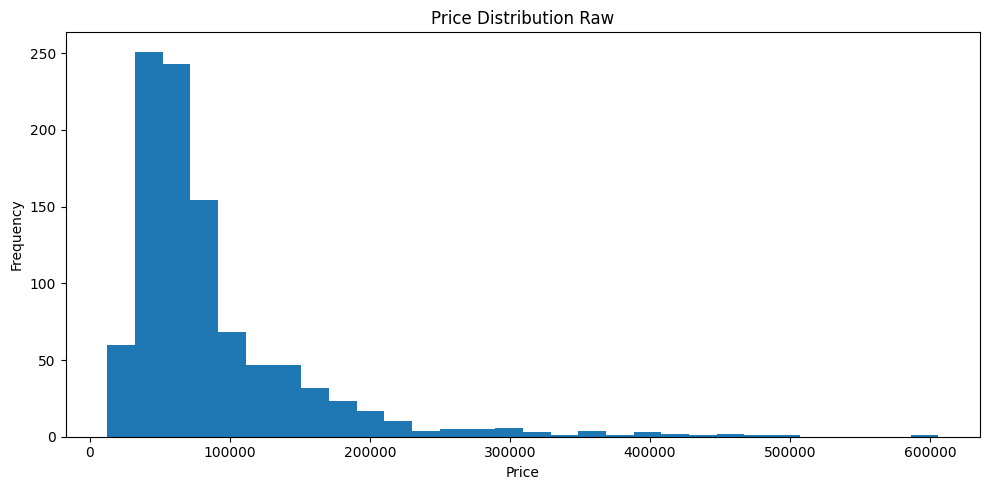

Saved plot to: ..\outputs\figures\price_distribution_raw.png


In [177]:
# Look at how tilted the price distribution is and what that might mean for modeling
price_skew = df_refined["price"].skew()
print("Price tilt:", round(price_skew, 4))

plt.figure(figsize=(10, 5))
plt.hist(df_refined["price"], bins=30)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Price Distribution Raw")
plt.tight_layout()

price_dist_path = FIGURES_DIR / "price_distribution_raw.png"
plt.savefig(price_dist_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved plot to: {price_dist_path}")


In [178]:
# Define feature set for next phase of modeling based on the EDA findings and feature engineering. Added some of the new featuresand some of the original features that were not dropped
feature_set_b = [
    "brand",
    "device_category",
    "rating",
    "cpu_brand",
    "cpu_family",
    "cpu_series",
    "cpu_core_count",
    "cpu_thread_count",
    "cpu_p_cores",
    "cpu_e_cores",
    "ram_gb",
    "storage_gb",
    "display_width_px",
    "display_height_px",
    "display_size_inch",
    "gpu_brand",
    "gpu_series",
    "gpu_type",
    "gpu_vram_gb",
    "os_name",
    "warranty_years",
    "total_pixels",
    "ppi",
    "threads_per_core",
    "has_dedicated_gpu",
    "gpu_vram_missing_flag",
    "cpu_p_cores_missing_flag",
    "cpu_e_cores_missing_flag",
]

feature_set_b_no_rating = [col for col in feature_set_b if col != "rating"]

print("Feature Set B size:", len(feature_set_b))
print("Feature Set B without rating size:", len(feature_set_b_no_rating))

Feature Set B size: 28
Feature Set B without rating size: 27


In [179]:
# Check for missing columns in the df for feature set B
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split

def make_dense_onehot():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

In [180]:
# Function to build preprocessors for the given feature set. Creating separate preprocessors for linear models, tree-based models, MLPs based on characteristics of features and requirements of the models
def build_preprocessors(X):
    numeric_features_local = X.select_dtypes(include=["number"]).columns.tolist()
    categorical_features_local = X.select_dtypes(exclude=["number"]).columns.tolist()

    categorical_transformer_sparse = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    categorical_transformer_dense = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", make_dense_onehot())
    ])

    numeric_transformer_linear = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    numeric_transformer_tree = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    numeric_transformer_mlp = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    preprocessor_linear_local = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer_linear, numeric_features_local),
            ("cat", categorical_transformer_sparse, categorical_features_local),
        ]
    )

    preprocessor_tree_local = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer_tree, numeric_features_local),
            ("cat", categorical_transformer_sparse, categorical_features_local),
        ]
    )

    preprocessor_mlp_local = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer_mlp, numeric_features_local),
            ("cat", categorical_transformer_dense, categorical_features_local),
        ],
        sparse_threshold=0
    )

    return (
        numeric_features_local,
        categorical_features_local,
        preprocessor_linear_local,
        preprocessor_tree_local,
        preprocessor_mlp_local
    )

In [181]:
# Function to run a feature experiment given a df, a list of features to use and label for the experiment.
def run_feature_experiment(df_input, feature_list, label):
    X = df_input[feature_list].copy()
    y = df_input["price"].copy()

    X_train_local, X_test_local, y_train_local, y_test_local = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE
    )

    (
        numeric_features_local,
        categorical_features_local,
        preprocessor_linear_local,
        preprocessor_tree_local,
        preprocessor_mlp_local
    ) = build_preprocessors(X_train_local)

    models_local = {
        f"Ridge_{label}": Pipeline(steps=[
            ("preprocessor", preprocessor_linear_local),
            ("model", Ridge(alpha=1.0))
        ]),
        f"RandomForest_{label}": Pipeline(steps=[
            ("preprocessor", preprocessor_tree_local),
            ("model", RandomForestRegressor(
                n_estimators=300,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ]),
        f"MLP_v2_{label}": Pipeline(steps=[
            ("preprocessor", preprocessor_mlp_local),
            ("model", MLPRegressor(
                hidden_layer_sizes=(128, 64),
                activation="relu",
                solver="adam",
                alpha=0.001,
                learning_rate_init=0.001,
                max_iter=800,
                random_state=RANDOM_STATE,
                early_stopping=True,
                validation_fraction=0.1,
                n_iter_no_change=25
            ))
        ])
    }

    rows = []
    fitted_models_local = {}
    predictions_local = {}

    for model_name, model in models_local.items():
        result, fitted_model, y_pred = evaluate_regressor(
            model=model,
            X_train=X_train_local,
            y_train=y_train_local,
            X_test=X_test_local,
            y_test=y_test_local,
            cv=cv,
            model_name=model_name
        )
        rows.append(result)
        fitted_models_local[model_name] = fitted_model
        predictions_local[model_name] = y_pred

    result_df = pd.DataFrame(rows).sort_values("test_rmse").reset_index(drop=True)

    return result_df, fitted_models_local, predictions_local, X_train_local, X_test_local, y_train_local, y_test_local

In [182]:
# Run the feature experiment with feature set B and the refined df
results_b, models_b, preds_b, X_train_b, X_test_b, y_train_b, y_test_b = run_feature_experiment(
    df_input=df_refined,
    feature_list=feature_set_b,
    label="feature_set_b"
)

results_b

,model,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,cv_r2_mean,cv_r2_std,test_rmse,test_mae,test_r2
0,MLP_v2_feature_set_b,21932.941119,1615.100155,13784.012663,811.379960,0.877054,0.027500,17937.836030,12231.072114,0.955936
1,Ridge_feature_set_b,19892.260924,1097.250037,12599.674072,609.602558,0.899973,0.013238,18675.551527,12834.102468,0.952238
2,RandomForest_feature_set_b,18226.628056,1485.226708,10941.596124,882.489853,0.915258,0.017557,23586.179527,12630.234502,0.923817


In [183]:
# Run the feature experiment with feature set B without rating feature to see how much the rating is contributing to the model performance and to test the model performance without it
results_b_no_rating, models_b_no_rating, preds_b_no_rating, X_train_b_nr, X_test_b_nr, y_train_b_nr, y_test_b_nr = run_feature_experiment(
    df_input=df_refined,
    feature_list=feature_set_b_no_rating,
    label="feature_set_b_no_rating"
)

results_b_no_rating

,model,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,cv_r2_mean,cv_r2_std,test_rmse,test_mae,test_r2
0,MLP_v2_feature_set_b_no_rating,22350.969470,1672.694811,13989.950001,909.909383,0.872064,0.029462,19807.768337,13773.205153,0.946271
1,Ridge_feature_set_b_no_rating,20155.720848,1059.483630,12549.139934,635.331922,0.897368,0.013065,19851.971864,12829.056046,0.946031
2,RandomForest_feature_set_b_no_rating,18200.873091,1296.293095,10700.557663,830.848070,0.915508,0.017086,23872.310760,12162.190307,0.921958


In [184]:
# Save the results of the feature set experiments
results_b_path = METRICS_DIR / "model_comparison_feature_set_b.csv"
results_b_no_rating_path = METRICS_DIR / "model_comparison_feature_set_b_no_rating.csv"

results_b.to_csv(results_b_path, index=False)
results_b_no_rating.to_csv(results_b_no_rating_path, index=False)

print(f"Saved: {results_b_path}")
print(f"Saved: {results_b_no_rating_path}")

Saved: ..\outputs\metrics\model_comparison_feature_set_b.csv
Saved: ..\outputs\metrics\model_comparison_feature_set_b_no_rating.csv


In [185]:
# Create a combined comparison of all models from the different experiments.
combined_model_comparison = pd.concat(
    [
        model_comparison_v3,
        results_b,
        results_b_no_rating
    ],
    ignore_index=True
).sort_values(by="test_rmse", ascending=True).reset_index(drop=True)

combined_model_comparison

,model,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,cv_r2_mean,cv_r2_std,test_rmse,test_mae,test_r2
0,MLP_v2_feature_set_b,21932.941119,1615.100155,13784.012663,811.379960,0.877054,0.027500,17937.836030,12231.072114,0.955936
1,Ridge_feature_set_b,19892.260924,1097.250037,12599.674072,609.602558,0.899973,0.013238,18675.551527,12834.102468,0.952238
2,Ridge,20616.708270,772.328554,13508.843119,480.360921,0.892535,0.013536,18899.182942,13544.408959,0.951087
3,MLP_v2,22850.717876,1074.005467,14938.996535,1047.128035,0.867612,0.020482,19750.219043,14299.907194,0.946582
4,MLP_v2_feature_set_b_no_rating,22350.969470,1672.694811,13989.950001,909.909383,0.872064,0.029462,19807.768337,13773.205153,0.946271
5,Ridge_feature_set_b_no_rating,20155.720848,1059.483630,12549.139934,635.331922,0.897368,0.013065,19851.971864,12829.056046,0.946031
6,RandomForest_feature_set_b,18226.628056,1485.226708,10941.596124,882.489853,0.915258,0.017557,23586.179527,12630.234502,0.923817
7,RandomForest,18687.778204,1463.715362,11374.818742,904.170832,0.910944,0.018086,23678.319671,12900.526213,0.923221
8,RandomForest_feature_set_b_no_rating,18200.873091,1296.293095,10700.557663,830.848070,0.915508,0.017086,23872.310760,12162.190307,0.921958
9,DummyRegressor,63407.589211,2744.891777,42614.173500,1820.671897,-0.008106,0.009222,86279.191190,53148.974133,-0.019418


In [186]:
# Save the combined comparison to csv
combined_comparison_path = METRICS_DIR / "model_comparison_combined.csv"
combined_model_comparison.to_csv(combined_comparison_path, index=False)

print(f"Saved: {combined_comparison_path}")

Saved: ..\outputs\metrics\model_comparison_combined.csv


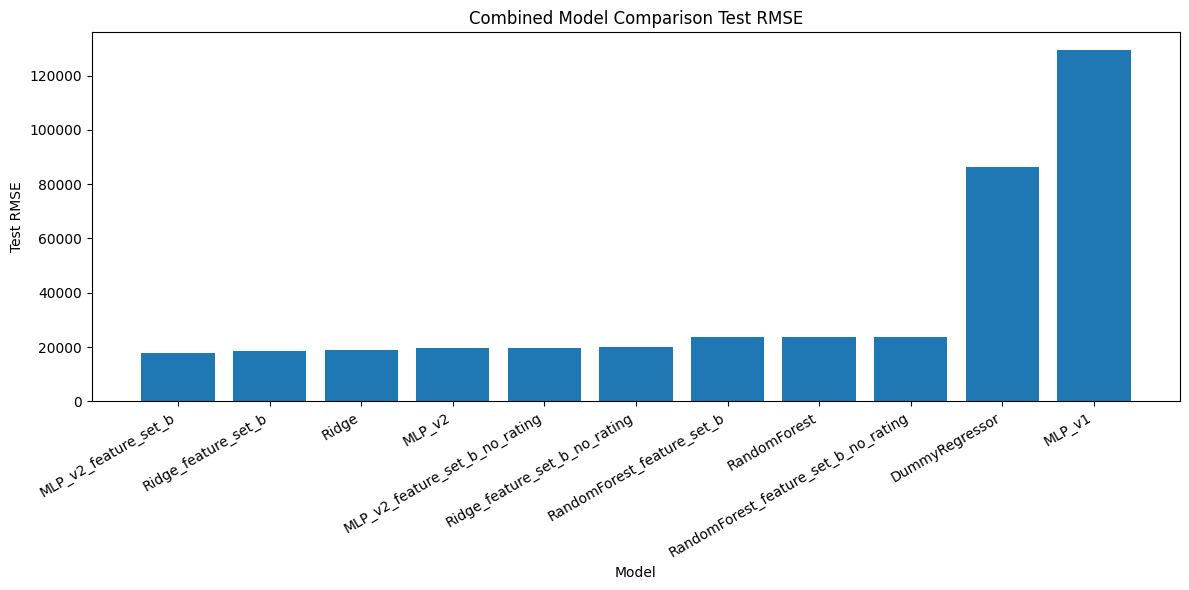

Saved: ..\outputs\figures\model_comparison_combined_test_rmse.png


In [187]:
# Create a bar plot of the test RMSE for each model
plot_df = combined_model_comparison.sort_values("test_rmse", ascending=True)

plt.figure(figsize=(12, 6))
plt.bar(plot_df["model"], plot_df["test_rmse"])
plt.ylabel("Test RMSE")
plt.xlabel("Model")
plt.title("Combined Model Comparison Test RMSE")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

combined_rmse_plot_path = FIGURES_DIR / "model_comparison_combined_test_rmse.png"
plt.savefig(combined_rmse_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {combined_rmse_plot_path}")

In [188]:
# Identify the best model by test RMSE in the current combined comparison and print its name
best_model_name = combined_model_comparison.iloc[0]["model"]
print("Best model by test RMSE in current comparison:", best_model_name)

Best model by test RMSE in current comparison: MLP_v2_feature_set_b


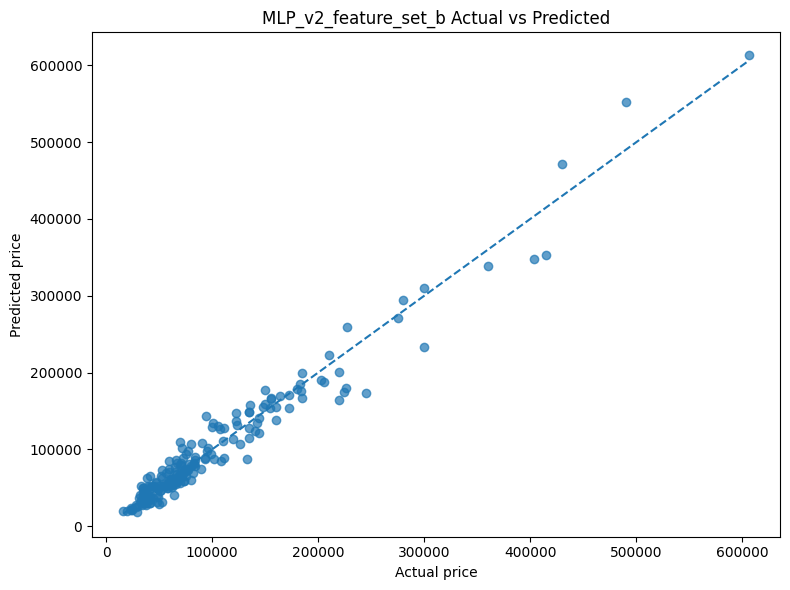

Saved: ..\outputs\figures\best_model_actual_vs_predicted.png


In [189]:
# If needed, infer the best model name from the combined comparison.
if "best_model_name" not in globals():
    best_model_name = combined_model_comparison.iloc[0]["model"]

# If the best model is from the current comparison set, plot actual vs predicted values.
if best_model_name in results_b["model"].values:
    y_actual_best = y_test_b.reset_index(drop=True)
    y_pred_best = pd.Series(preds_b[best_model_name]).reset_index(drop=True)
elif best_model_name in results_b_no_rating["model"].values:
    y_actual_best = y_test_b_nr.reset_index(drop=True)
    y_pred_best = pd.Series(preds_b_no_rating[best_model_name]).reset_index(drop=True)
else:
    y_actual_best = None
    y_pred_best = None

if y_actual_best is not None:
    plt.figure(figsize=(8, 6))
    plt.scatter(y_actual_best, y_pred_best, alpha=0.7)
    plt.plot(
        [y_actual_best.min(), y_actual_best.max()],
        [y_actual_best.min(), y_actual_best.max()],
        linestyle="--"
    )
    plt.xlabel("Actual price")
    plt.ylabel("Predicted price")
    plt.title(f"{best_model_name} Actual vs Predicted")
    plt.tight_layout()

    best_actual_pred_path = FIGURES_DIR / "best_model_actual_vs_predicted.png"
    plt.savefig(best_actual_pred_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved: {best_actual_pred_path}")
else:
    print("Current best model is from an earlier comparison set.")

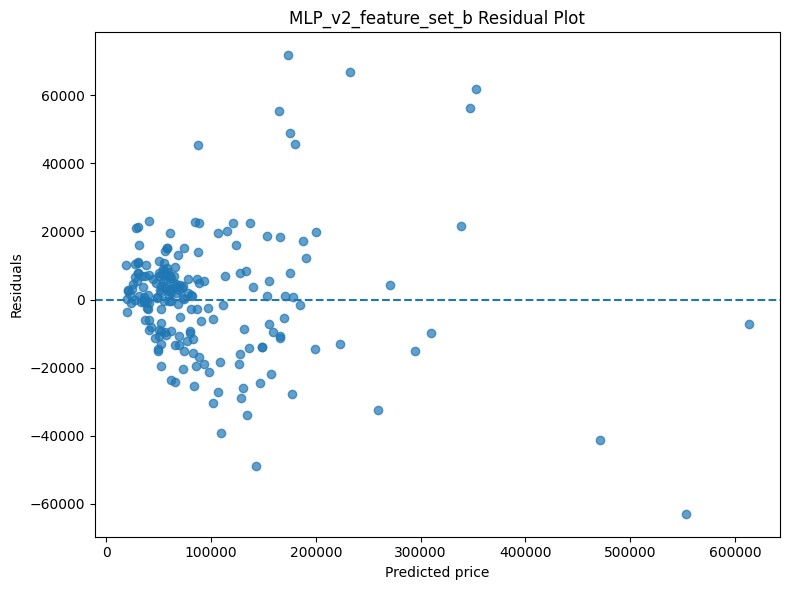

Saved: ..\outputs\figures\best_model_residual_plot.png


In [190]:
# Plot residuals for the current best-model predictions if available.
if "y_actual_best" in globals() and y_actual_best is not None:
    residuals_best = y_actual_best - y_pred_best

    plt.figure(figsize=(8, 6))
    plt.scatter(y_pred_best, residuals_best, alpha=0.7)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Predicted price")
    plt.ylabel("Residuals")
    plt.title(f"{best_model_name} Residual Plot")
    plt.tight_layout()

    best_residual_path = FIGURES_DIR / "best_model_residual_plot.png"
    plt.savefig(best_residual_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved: {best_residual_path}")
else:
    print("Run the previous best-model prediction plot cell first to generate residuals.")